# 👕 T-Shirt Image & Text Retrieval System
This project implements an end-to-end multi-modal retrieval system using state-of-the-art pretrained models from Hugging Face. The pipeline is divided into three main tasks:

1. **Image Retrieval (CLIP):** Zero-shot text-to-image retrieval using OpenAI's CLIP.
2. **Image Captioning (BLIP):** Generating descriptive captions for the dataset images.
3. **Text Retrieval & Reranking:** Dense vector search using ChromaDB and BGE embeddings, refined by a Cross-Encoder reranker.

[Dataset: 1,993 T-Shirt images from Kaggle.](https://www.kaggle.com/datasets/danizo/applied-data-mining-final-project-t-shirt-data)

In [5]:
# Install required libraries
!pip install -q torch torchvision transformers==4.43.4 pillow chromadb sentence-transformers accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 94.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 67.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 43.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 97.0 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 63.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 4.2 MB/s eta 0:00:00
 

In [6]:
import os
import gc
import json
import time
import logging
import textwrap
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm # Use notebook version of tqdm for better UI

import torch
import torch.nn.functional as F
from transformers import (
    CLIPProcessor, 
    CLIPModel, 
    BlipProcessor, 
    BlipForConditionalGeneration
)
from sentence_transformers import SentenceTransformer, CrossEncoder
import chromadb

# ==========================================
# System Setup & Logging
# ==========================================
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S"
)
logger = logging.getLogger("IR_Pipeline")

# Suppress verbose HTTP logs
logging.getLogger("httpx").setLevel(logging.WARNING)
logging.getLogger("urllib3").setLevel(logging.WARNING)
logging.getLogger("transformers").setLevel(logging.ERROR)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
logger.info(f"Pipeline running on device: {DEVICE}")

00:08:23 [INFO] Pipeline running on device: cuda


## Task 1: Image Retrieval (CLIP)
Using `openai/clip-vit-base-patch32` to project both images and text into the same latent space. We compute the cosine similarity between the textual query and all images to find the best visual matches.

In [7]:
class ImageRetriever:
    def __init__(self, model_id="openai/clip-vit-base-patch32", device=DEVICE):
        logger.info(f"[Task 1] Loading CLIP model '{model_id}'...")
        self.device = device
        self.model = CLIPModel.from_pretrained(model_id).to(self.device)
        self.processor = CLIPProcessor.from_pretrained(model_id)
        self.model.eval()
        self.image_embeddings = {}

    def _extract_tensor(self, output):
        if isinstance(output, torch.Tensor):
            return output
        if hasattr(output, "image_embeds") and output.image_embeds is not None:
            return output.image_embeds
        if hasattr(output, "text_embeds") and output.text_embeds is not None:
            return output.text_embeds
        if hasattr(output, "pooler_output") and output.pooler_output is not None:
            return output.pooler_output
        return output[0]

    def embed_dataset(self, image_dir: str, batch_size: int = 64):
        valid_exts = ('.png', '.jpg', '.jpeg')
        image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_exts)]
        logger.info(f"[Task 1] Extracting embeddings for {len(image_files)} images (batch size {batch_size})...")
        
        start_time = time.time()
        for i in tqdm(range(0, len(image_files), batch_size), desc="Task 1/3: CLIP Image Embedding", unit="batch"):
            batch_names = image_files[i:i + batch_size]
            batch_images = []
            valid_names = []

            for name in batch_names:
                try:
                    img = Image.open(os.path.join(image_dir, name)).convert("RGB")
                    batch_images.append(img)
                    valid_names.append(name)
                except Exception:
                    continue

            if not batch_images:
                continue

            inputs = self.processor(images=batch_images, return_tensors="pt", padding=True).to(self.device)
            with torch.no_grad():
                embeds = self.model.get_image_features(**inputs)
                embeds = self._extract_tensor(embeds)
                embeds = embeds / embeds.norm(dim=-1, keepdim=True)

            for name, emb in zip(valid_names, embeds.cpu()):
                self.image_embeddings[name] = emb.unsqueeze(0)

        elapsed = time.time() - start_time
        logger.info(f"[Task 1] Embedded {len(self.image_embeddings)} images in {elapsed:.2f}s.")

    def search(self, query: str, top_k: int = 5):
        inputs = self.processor(text=[query], return_tensors="pt", padding=True).to(self.device)
        with torch.no_grad():
            text_embed = self.model.get_text_features(**inputs)
            text_embed = self._extract_tensor(text_embed)
            text_embed = text_embed / text_embed.norm(dim=-1, keepdim=True)
            text_embed = text_embed.cpu()

        results = {}
        for img_name, img_embed in self.image_embeddings.items():
            sim = F.cosine_similarity(text_embed, img_embed).item()
            results[img_name] = sim

        return sorted(results.items(), key=lambda x: x[1], reverse=True)[:top_k]

## Task 2: Image Captioning (BLIP)
Using `Salesforce/blip-image-captioning-base` to automatically generate descriptive text for every T-shirt in the dataset. This enables text-based indexing in the next step.

In [8]:
class ImageCaptioner:
    def __init__(self, model_id="Salesforce/blip-image-captioning-base", device=DEVICE):
        logger.info(f"[Task 2] Loading BLIP Captioning Model '{model_id}'...")
        self.device = device
        self.processor = BlipProcessor.from_pretrained(model_id)
        self.model = BlipForConditionalGeneration.from_pretrained(model_id).to(self.device)
        self.model.eval()

    def generate_captions(self, image_dir: str, output_file="tshirt_captions.json", batch_size: int = 32):
        valid_exts = ('.png', '.jpg', '.jpeg')
        image_files = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_exts)]

        captions = {}
        if os.path.exists(output_file):
            try:
                with open(output_file, "r") as f:
                    captions = json.load(f)
                logger.info(f"[Task 2] Resumed from checkpoint: {len(captions)} already processed.")
            except Exception:
                captions = {}

        pending_files = [f for f in image_files if f not in captions]
        logger.info(f"[Task 2] Generating captions for {len(pending_files)} remaining images...")
        start_time = time.time()

        for i in tqdm(range(0, len(pending_files), batch_size), desc="Task 2/3: Generating Captions", unit="batch"):
            batch_names = pending_files[i:i + batch_size]
            batch_images = []
            valid_names = []

            for name in batch_names:
                try:
                    img = Image.open(os.path.join(image_dir, name)).convert("RGB")
                    batch_images.append(img)
                    valid_names.append(name)
                except Exception:
                    continue

            if not batch_images:
                continue

            prompt = ["a photo of a t-shirt featuring"] * len(batch_images)
            inputs = self.processor(images=batch_images, text=prompt, return_tensors="pt", padding=True).to(self.device)

            with torch.no_grad():
                out = self.model.generate(**inputs, max_new_tokens=50)
                decoded = self.processor.batch_decode(out, skip_special_tokens=True)

            for name, cap in zip(valid_names, decoded):
                captions[name] = cap

            # Periodic checkpoint save
            with open(output_file, "w") as f:
                json.dump(captions, f, indent=4)

        elapsed = time.time() - start_time
        logger.info(f"[Task 2] Captions saved to '{output_file}' in {elapsed:.2f}s.")
        return captions

## Task 3: Text Retrieval (ChromaDB + BGE)
We embed the generated captions using `bge-small-en-v1.5` and store them in ChromaDB for fast retrieval. To maximize accuracy, the top-N results are reranked using a Cross-Encoder (`bge-reranker-base`).

In [9]:
class TextRetriever:
    def __init__(self, embedding_model="BAAI/bge-small-en-v1.5", reranker_model="BAAI/bge-reranker-base", device=DEVICE):
        logger.info(f"[Task 3] Initializing Dense Retriever and Cross-Encoder...")
        self.encoder = SentenceTransformer(embedding_model, device=device)
        self.reranker = CrossEncoder(reranker_model, device=device)
        
        self.chroma_client = chromadb.Client()
        try:
            self.chroma_client.delete_collection("tshirt_captions")
        except Exception:
            pass
        self.collection = self.chroma_client.create_collection(name="tshirt_captions")

    def index_captions(self, captions_dict: dict, batch_size: int = 128):
        logger.info(f"[Task 3] Embedding {len(captions_dict)} documents into ChromaDB...")
        ids = list(captions_dict.keys())
        documents = list(captions_dict.values())

        embeddings = self.encoder.encode(
            documents, 
            normalize_embeddings=True, 
            batch_size=batch_size, 
            show_progress_bar=True
        ).tolist()

        for i in range(0, len(ids), batch_size):
            self.collection.add(
                ids=ids[i:i + batch_size],
                embeddings=embeddings[i:i + batch_size],
                documents=documents[i:i + batch_size]
            )
        logger.info(f"[Task 3] Successfully indexed {len(ids)} captions.")

    def search(self, query: str, top_k: int = 5, retrieve_n: int = 25):
        query_embedding = self.encoder.encode(query, normalize_embeddings=True).tolist()
        results = self.collection.query(query_embeddings=[query_embedding], n_results=retrieve_n)

        retrieved_ids = results['ids'][0]
        retrieved_docs = results['documents'][0]

        # Step 2: Cross-Encoder Reranking
        cross_inp = [[query, doc] for doc in retrieved_docs]
        cross_scores = self.reranker.predict(cross_inp)

        reranked_results = list(zip(retrieved_ids, retrieved_docs, cross_scores))
        reranked_results.sort(key=lambda x: x[2], reverse=True)
        return reranked_results[:top_k]

## Utilities: Visualization
A helper function to display the results of Task 1 (CLIP) and Task 3 (Text Reranking) side-by-side for qualitative comparison.

In [10]:
def visualize_retrieval_comparison(
    query: str,
    clip_results: list,
    text_results: list,
    image_dir: str,
    save_path: str = "retrieval_comparison.png"
):
    """
    Renders a 2-row comparison grid:
      - Row 1: Task 1 CLIP Zero-Shot Visual Retrieval
      - Row 2: Task 3 Text Caption Retrieval + Cross-Encoder Reranking
    """
    k = max(len(clip_results), len(text_results))
    fig, axes = plt.subplots(2, k, figsize=(4.5 * k, 10))
    
    fig.suptitle(f"Search Query: \"{query}\"", fontsize=15, fontweight="bold", y=0.98)

    # ---------------------------------------------------------
    # Row 1: Task 1 (CLIP Visual Matching)
    # ---------------------------------------------------------
    for col_idx in range(k):
        ax = axes[0, col_idx] if k > 1 else axes[0]
        if col_idx < len(clip_results):
            img_name, score = clip_results[col_idx]
            img_path = os.path.join(image_dir, img_name)
            
            if os.path.exists(img_path):
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
            
            ax.set_title(
                f"Rank #{col_idx + 1} | CLIP Score: {score:.4f}\n{img_name}",
                fontsize=10,
                fontweight="semibold",
                pad=6
            )
        ax.set_xticks([])
        ax.set_yticks([])

    axes[0, 0].text(
        -0.2, 0.5, "Task 1:\nCLIP (Visual)",
        transform=axes[0, 0].transAxes,
        fontsize=12, fontweight="bold",
        va="center", ha="right", color="#1f77b4"
    )

    # ---------------------------------------------------------
    # Row 2: Task 3 (Text Caption + Reranker)
    # ---------------------------------------------------------
    for col_idx in range(k):
        ax = axes[1, col_idx] if k > 1 else axes[1]
        if col_idx < len(text_results):
            img_name, caption, score = text_results[col_idx]
            img_path = os.path.join(image_dir, img_name)
            
            if os.path.exists(img_path):
                img = Image.open(img_path).convert("RGB")
                ax.imshow(img)
            
            ax.set_title(
                f"Rank #{col_idx + 1} | Rerank Score: {score:.2f}\n{img_name}",
                fontsize=10,
                fontweight="semibold",
                pad=6
            )
            
            wrapped_caption = "\n".join(textwrap.wrap(caption, width=30))
            ax.set_xlabel(wrapped_caption, fontsize=8.5, color="#2c3e50", labelpad=8)
            
        ax.set_xticks([])
        ax.set_yticks([])

    axes[1, 0].text(
        -0.2, 0.5, "Task 3:\nText Reranked",
        transform=axes[1, 0].transAxes,
        fontsize=12, fontweight="bold",
        va="center", ha="right", color="#2ca02c"
    )

    plt.tight_layout(rect=[0.08, 0.03, 1, 0.94])
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    logger.info(f"Comparison plot saved to '{save_path}'.")

## Run Pipeline
Execute the full process end-to-end on a test query. This step handles memory cleanup (`gc.collect()` and `empty_cache()`) between models to ensure it runs smoothly on standard GPU environments.

00:08:23 [INFO] Target dataset directory: /kaggle/input/datasets/danizo/applied-data-mining-final-project-t-shirt-data/tshirt
00:08:23 [INFO] === TASK 1: CLIP ZERO-SHOT RETRIEVAL ===
00:08:23 [INFO] [Task 1] Loading CLIP model 'openai/clip-vit-base-patch32'...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

00:17:42 [INFO] [Task 3] Successfully indexed 1993 captions.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

00:17:42 [INFO] === PIPELINE COMPLETED SUCCESSFULLY ===



--- Task 3 Top Results (BGE + Cross-Encoder Reranked) ---
[1] Image: 234.jpg | Reranker Score: 0.9996
    Caption: a photo of a t - shirt featuring the logo for the band

[2] Image: 1298.jpg | Reranker Score: 0.9996
    Caption: a photo of a t - shirt featuring the logo for the band

[3] Image: 623.jpg | Reranker Score: 0.9996
    Caption: a photo of a t - shirt featuring the logo of the band

--------------------------------------------------


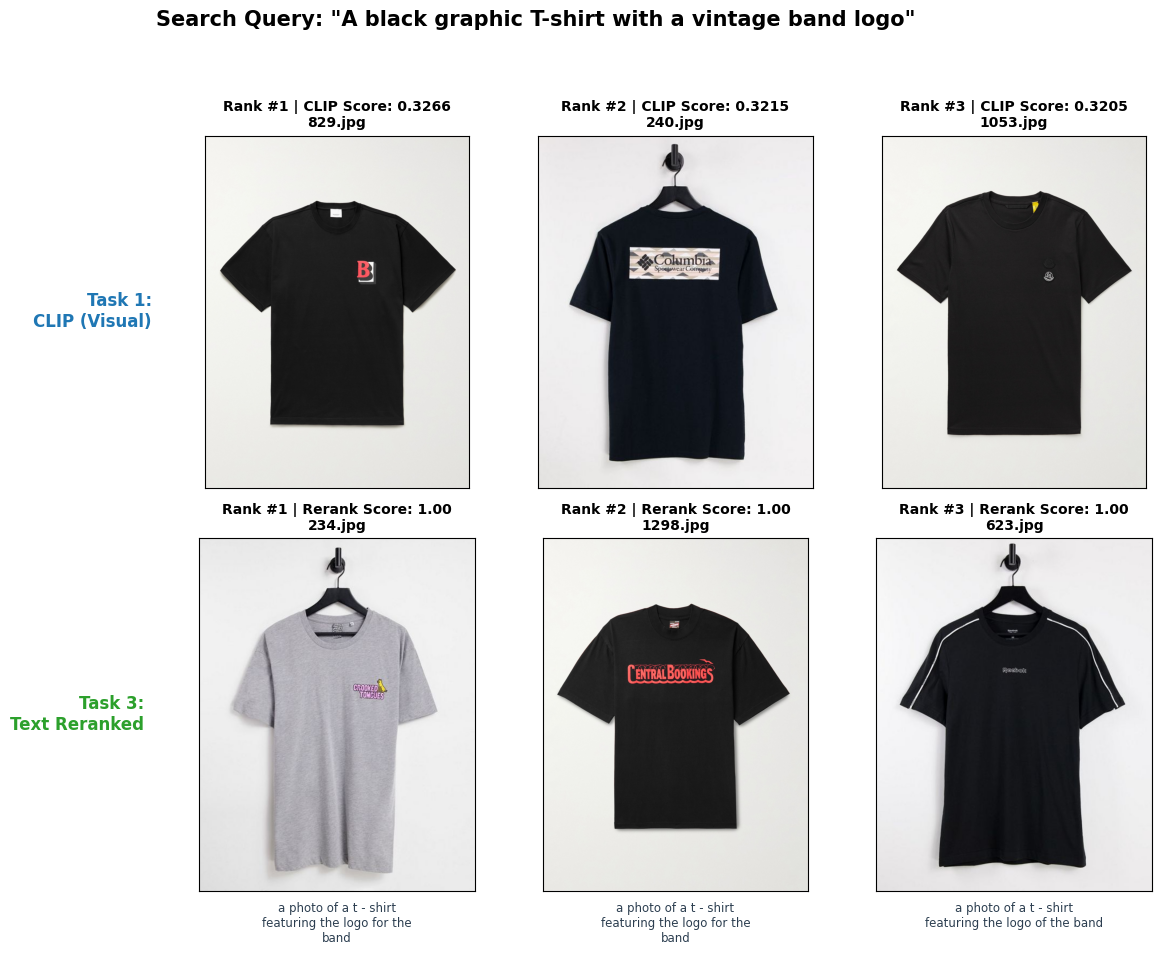

00:17:47 [INFO] Comparison plot saved to 'tshirt_retrieval_comparison.png'.


In [11]:
# Adjust this path if your folder structure differs
DATASET_DIR = "./dataset/images"
if not os.path.exists(DATASET_DIR) or len(os.listdir(DATASET_DIR)) == 0:
    # Common Kaggle dataset fallback paths
    alt_paths = [
        "/kaggle/input/applied-data-mining-final-project-t-shirt-data/tshirt",
        "/kaggle/input/datasets/danizo/applied-data-mining-final-project-t-shirt-data/tshirt",
        "./tshirt"
    ]
    for p in alt_paths:
        if os.path.exists(p) and len(os.listdir(p)) > 0:
            DATASET_DIR = p
            break

CAPTIONS_FILE = "tshirt_captions.json"
TEST_QUERY = "A black graphic T-shirt with a vintage band logo"

logger.info(f"Target dataset directory: {DATASET_DIR}")

# --- TASK 1: Image Retrieval ---
logger.info("=== TASK 1: CLIP ZERO-SHOT RETRIEVAL ===")
clip_retriever = ImageRetriever()
clip_retriever.embed_dataset(DATASET_DIR, batch_size=64)

top_images = clip_retriever.search(TEST_QUERY, top_k=3)
print("\n--- Task 1 Top Results (CLIP Direct Visual Match) ---")
for rank, (img_name, score) in enumerate(top_images, 1):
    print(f"[{rank}] Image: {img_name} | Cosine Similarity: {score:.4f}")
print("-" * 50 + "\n")

# Clear memory
del clip_retriever
gc.collect()
torch.cuda.empty_cache()

# --- TASK 2: Image Captioning ---
logger.info("=== TASK 2: IMAGE CAPTIONING ===")
captioner = ImageCaptioner()
captions = captioner.generate_captions(DATASET_DIR, output_file=CAPTIONS_FILE, batch_size=32)

# Clear memory
del captioner
gc.collect()
torch.cuda.empty_cache()

# --- TASK 3: Text Retrieval & Reranking ---
logger.info("=== TASK 3: TEXT RETRIEVAL & RERANKING ===")
text_retriever = TextRetriever()
text_retriever.index_captions(captions)

top_text_results = text_retriever.search(TEST_QUERY, top_k=3)
print("\n--- Task 3 Top Results (BGE + Cross-Encoder Reranked) ---")
for rank, (img_name, doc, score) in enumerate(top_text_results, 1):
    print(f"[{rank}] Image: {img_name} | Reranker Score: {score:.4f}")
    print(f"    Caption: {doc}\n")
print("-" * 50)
logger.info("=== PIPELINE COMPLETED SUCCESSFULLY ===")

# --- VISUALIZATION ---
# Format Task 3 results to pass (img_name, caption, score)
top_text_formatted = [(img_name, doc, score) for img_name, doc, score in top_text_results]

visualize_retrieval_comparison(
    query=TEST_QUERY,
    clip_results=top_images,
    text_results=top_text_formatted,
    image_dir=DATASET_DIR,
    save_path="tshirt_retrieval_comparison.png"
)